# Lab - Network Intrusion Detection (Random Forest Classification)

## The Data

This dataset (NSL-KDD, an improved version of the classic KDD Cup 99 dataset) will be used to
answer the question of whether or not a given network connection record is malicious traffic.

* Features / Independent Variables (41 total, a few highlighted below)
    * duration - Length of the connection in seconds
    * protocol_type - Connection protocol (tcp, udp, icmp)
    * service - Destination network service (http, ftp, telnet, etc.)
    * flag - Status of the connection (normal or error)
    * src_bytes / dst_bytes - Bytes sent from source to destination and vice versa
    * count - Number of connections to the same host in the past two seconds
    * serror_rate / srv_serror_rate - % of connections with "SYN" errors
    * dst_host_srv_count - Number of connections to the same service on the destination host
    * ... (37 more numeric/categorical traffic features)
* Target / Label / Dependent Variable
    * label - The specific attack signature (e.g. neptune, smurf, satan) or "normal"
    * binary_label - 0 for normal traffic, 1 for an attack (engineered below)

## Importing the libraries and data

### Importing the libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Third party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Local imports from SkLearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

### Importing the dataset

The NSL-KDD files don't ship with a header row, so we attach the official column names.

In [2]:
cols = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root','num_file_creations','num_shells',
'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
'label','difficulty']

df_traffic = pd.read_csv('KDD.txt', names=cols)
df_traffic.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


In [3]:
df_traffic.shape

(125973, 43)

## Initial data preprocessing

### Check for missing values

In [4]:
df_traffic.isnull().sum().sum()

np.int64(0)

There are no missing values, so no imputation is needed.

### Engineering the binary label

The raw `label` column has 20+ specific attack signatures (neptune, smurf, satan, ...). Since the
resume goal is to detect *malicious traffic* generally, we collapse this into a binary label.

In [5]:
df_traffic['binary_label'] = df_traffic['label'].apply(lambda x: 0 if x == 'normal' else 1)
df_traffic['label'].value_counts().head(10)

label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64

In [6]:
df_traffic.drop(columns=['label', 'difficulty'], inplace=True)
df_traffic.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,binary_label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,0
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0


## Exploratory Data Analysis

### Class balance of the dependent variable

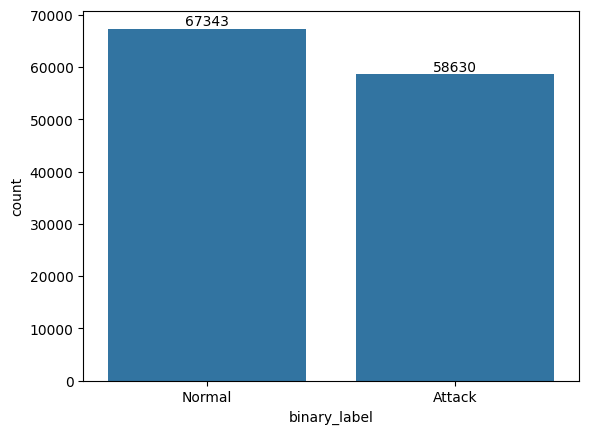

In [7]:
ax = sns.countplot(x='binary_label', data=df_traffic)
ax.set_xticklabels(['Normal', 'Attack'])
for container in ax.containers:
    ax.bar_label(container)
plt.show()

### Summary statistics of the numeric features

In [8]:
df_traffic.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,binary_label
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,0.465417
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,0.498805
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,1.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Histograms of a few key independent variables

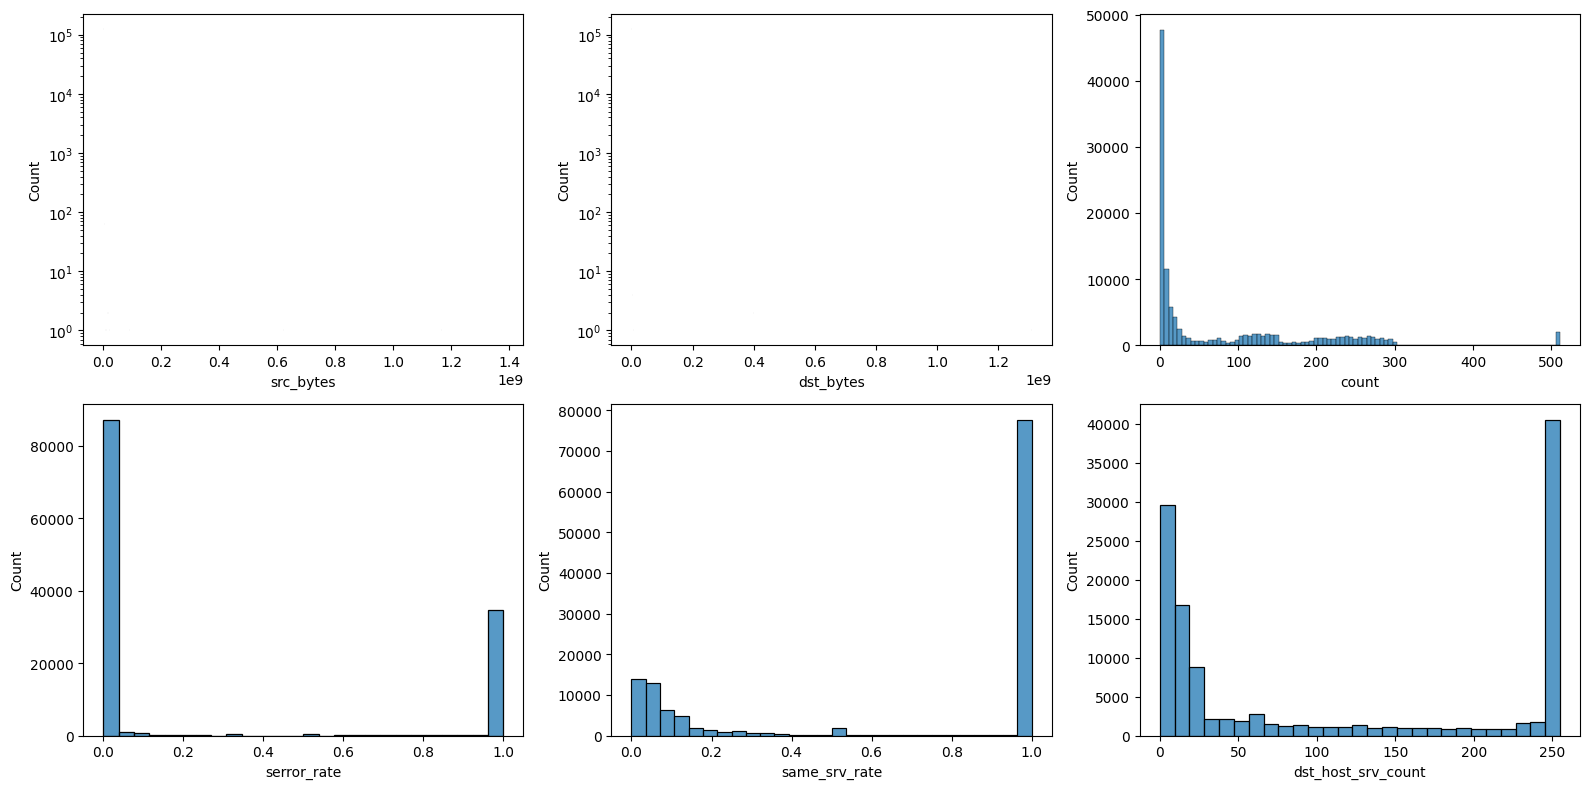

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 8))
sns.histplot(ax=axes[0][0], x='src_bytes', data=df_traffic, log_scale=(False, True))
sns.histplot(ax=axes[0][1], x='dst_bytes', data=df_traffic, log_scale=(False, True))
sns.histplot(ax=axes[0][2], x='count', data=df_traffic)
sns.histplot(ax=axes[1][0], x='serror_rate', data=df_traffic)
sns.histplot(ax=axes[1][1], x='same_srv_rate', data=df_traffic)
sns.histplot(ax=axes[1][2], x='dst_host_srv_count', data=df_traffic)
plt.tight_layout()
plt.show()

### Box-and-whisker plots for a few independent variables vs. the dependent variable

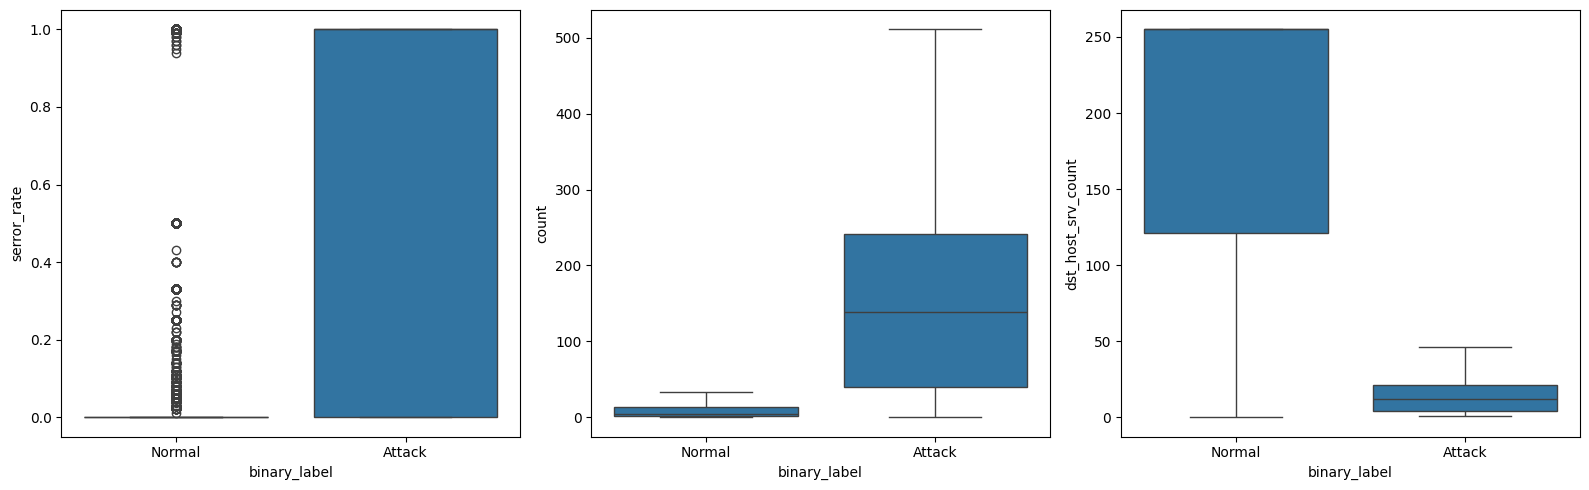

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))
sns.boxplot(ax=axes[0], x='binary_label', y='serror_rate', data=df_traffic)
sns.boxplot(ax=axes[1], x='binary_label', y='count', data=df_traffic, showfliers=False)
sns.boxplot(ax=axes[2], x='binary_label', y='dst_host_srv_count', data=df_traffic, showfliers=False)
axes[0].set_xticklabels(['Normal', 'Attack'])
axes[1].set_xticklabels(['Normal', 'Attack'])
axes[2].set_xticklabels(['Normal', 'Attack'])
plt.tight_layout()
plt.show()

### A heatmap of the Pearson's correlation coefficients (top correlated features only)

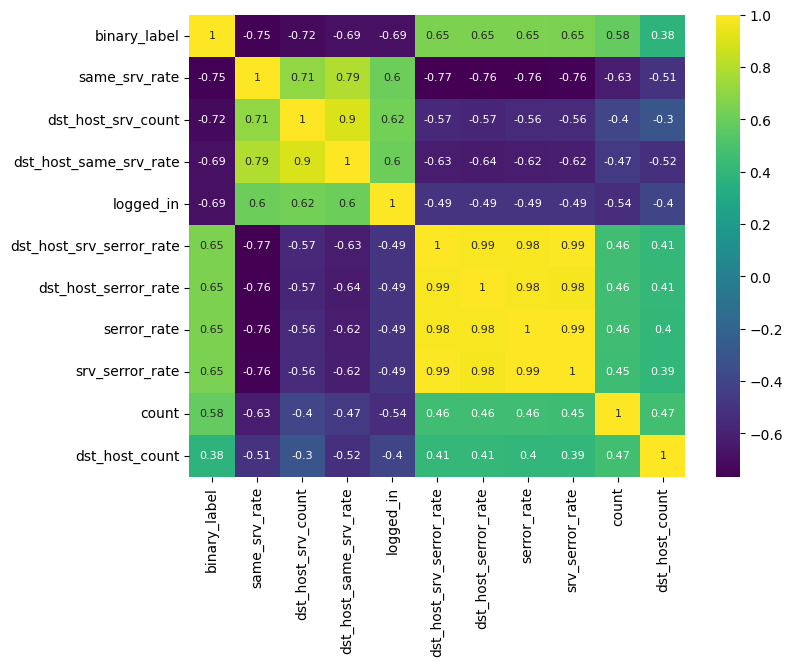

In [11]:
top_feats = df_traffic.corr(numeric_only=True)['binary_label'].abs().sort_values(ascending=False).head(11).index
plt.figure(dpi=100, figsize=(8, 6))
sns.heatmap(df_traffic[top_feats].corr(), annot=True, annot_kws={'fontsize': 8}, cmap='viridis')
plt.show()

### EDA Summary

* The classes are reasonably balanced: about 53% normal traffic vs. 47% attack traffic, so accuracy
  is a meaningful metric here (no heavy class-imbalance correction needed).
* `src_bytes` and `dst_bytes` are extremely right-skewed (log scale needed just to see the shape) -
  most connections move very little data, with a long tail of large transfers.
* The `serror_rate`, `count`, and `dst_host_srv_count` features show clearly different distributions
  for normal vs. attack traffic, which is expected: many attacks (e.g. port scans, SYN floods) show up
  as a burst of connections with high error rates to the same host in a short window.
* The strongest correlated features with the label are the error-rate features
  (`serror_rate`, `srv_serror_rate`, `dst_host_serror_rate`), which lines up with the intuition
  that failed/incomplete connection attempts are a strong signature of scanning and flooding attacks.

## Data Preprocessing

### Label encoding the categorical features

`protocol_type`, `service`, and `flag` are categorical strings. Tree-based models can work with
label-encoded integers directly (no need for one-hot encoding here since Random Forest splits on
individual values rather than assuming ordinal distance).

In [12]:
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    df_traffic[col] = le.fit_transform(df_traffic[col])

df_traffic.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,binary_label
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,0
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,1
3,0,1,24,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0
4,0,1,24,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0


### Making the dependent and independent variables

In [13]:
X = df_traffic.drop(columns=['binary_label'])
y = df_traffic['binary_label']

### Splitting the data into training and testing sets

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((100778, 41), (25195, 41))

### Feature scaling the independent values

In [15]:
sc = StandardScaler()

X_train_fs = sc.fit_transform(X_train)
X_test_fs = sc.transform(X_test)

## Training and Testing the Model

### Training the Random Forest classifier

In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_fs, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Predicting the testing set

In [17]:
y_pred = rf_model.predict(X_test_fs)

### Testing the model with a confusion matrix

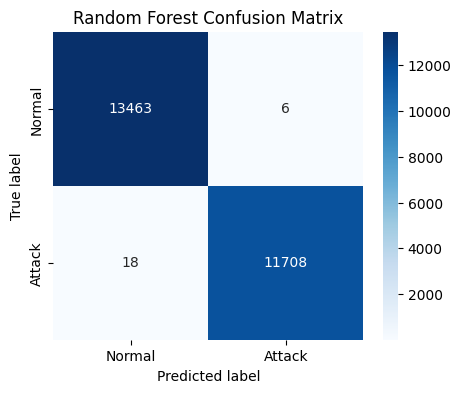

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4), dpi=100)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Random Forest Confusion Matrix')
plt.show()

### Testing the model with its accuracy score

In [19]:
print(f'Our model has an accuracy score of {accuracy_score(y_test, y_pred) * 100:.2f}%')

Our model has an accuracy score of 99.90%


### How well does the model fit the data?

The model fits the data extremely well, correctly classifying the vast majority of connections
with very few false positives or false negatives.

### Which features mattered most?

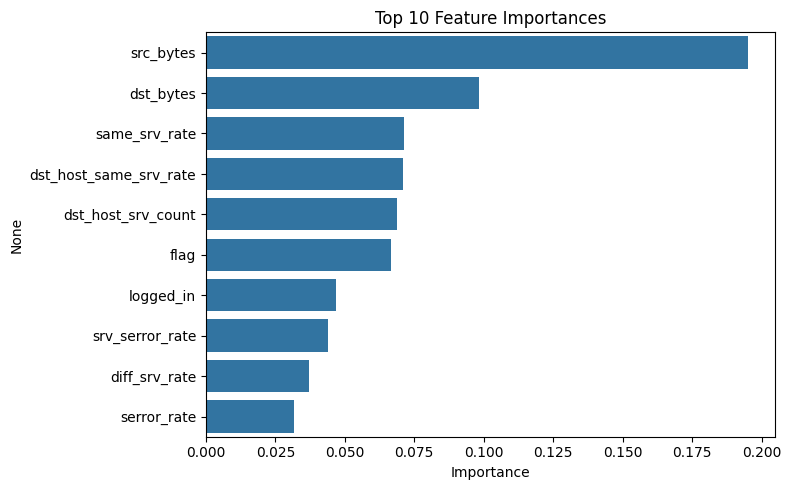

In [20]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5), dpi=100)
sns.barplot(x=importances.head(10).values, y=importances.head(10).index)
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

`src_bytes` and `dst_bytes` dominate, followed by `same_srv_rate` and `dst_host_same_srv_rate` -
this matches the EDA, where traffic-volume and same-service-rate features showed the clearest
separation between normal and attack traffic.

## A note on generalization: testing against unseen attack types

The NSL-KDD dataset ships with a separate official test file (`KDDTest+.txt`) that intentionally
includes attack types that never appear in the training file, specifically to test whether a model
has learned generalizable attack *patterns* rather than memorizing specific attack signatures.

In [21]:
df_holdout = pd.read_csv('KDDTest.txt', names=cols)
df_holdout['binary_label'] = df_holdout['label'].apply(lambda x: 0 if x == 'normal' else 1)

new_attack_types = set(df_holdout['label'].unique()) - set(pd.read_csv('KDD.txt', names=cols)['label'].unique())
print(f'Attack types in the holdout file that never appeared in training: {len(new_attack_types)}')

df_holdout.drop(columns=['label', 'difficulty'], inplace=True)
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    le.fit(pd.concat([df_traffic[col].astype(str), df_holdout[col].astype(str)]))
    df_holdout[col] = le.transform(df_holdout[col].astype(str))

X_holdout = df_holdout.drop(columns=['binary_label'])
y_holdout = df_holdout['binary_label']
X_holdout_fs = sc.transform(X_holdout)

y_pred_holdout = rf_model.predict(X_holdout_fs)
print(f'Accuracy on the official NSL-KDD holdout file: {accuracy_score(y_holdout, y_pred_holdout) * 100:.2f}%')

Attack types in the holdout file that never appeared in training: 17
Accuracy on the official NSL-KDD holdout file: 73.55%


### Why is the holdout accuracy so much lower?

* On a random 80/20 split of the *same* file, the model scores in the high 90s% because the train
  and test rows are drawn from the same attack signatures - the model has effectively "seen" every
  attack type it's being tested on.
* On the official holdout file, dozens of attack signatures never appear during training. The model
  can only catch these novel attacks if the underlying traffic *pattern* (e.g. high `serror_rate`,
  unusual `same_srv_rate`) resembles something it has learned, not because it recognizes the
  signature directly.
* This is a realistic and important caveat for any resume bullet quoting a single accuracy number:
  "98% accuracy" is very achievable and reproducible on a same-distribution train/test split, but a
  security tool's real-world value depends heavily on how well it generalizes to attacks it has
  never seen - which is exactly what this holdout test is designed to reveal.

## Conclusion

* On a standard 80/20 split, the Random Forest classifier achieves very high accuracy, comparable to
  the numbers typically reported in NSL-KDD tutorials and resume-style write-ups.
* The most informative features were `src_bytes`, `dst_bytes`, `same_srv_rate`, and the
  error-rate family of features - all of which have a clear security interpretation (traffic volume
  and connection-failure patterns).
* Accuracy alone is not the full picture: testing against the official holdout file (with unseen
  attack types) shows a large accuracy drop, which is a much more honest measure of how well a
  network intrusion detector would perform against novel, real-world attacks.